In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
uber_data_set="/Users/canberkyilmaz/Desktop/UberDataset.csv"
dataset=pd.read_csv(uber_data_set)
dataset.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [5]:
dataset.shape

(1156, 7)

In [6]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   str    
 1   END_DATE    1155 non-null   str    
 2   CATEGORY    1155 non-null   str    
 3   START       1155 non-null   str    
 4   STOP        1155 non-null   str    
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    str    
dtypes: float64(1), str(6)
memory usage: 63.3 KB


In [9]:
dataset['PURPOSE']=dataset["PURPOSE"].fillna("NOT")

In [11]:
dataset['START_DATE'] = pd.to_datetime(dataset['START_DATE'], errors='coerce')
dataset['END_DATE'] = pd.to_datetime(dataset['END_DATE'], errors='coerce')

In [12]:
from datetime import datetime

In [14]:
dataset["date"]=pd.DatetimeIndex(dataset["START_DATE"]).date

In [15]:
dataset["time"]=pd.DatetimeIndex(dataset["START_DATE"]).hour

In [16]:
dataset["day-night"]=pd.cut(
    x=dataset["time"],
    bins=[0,10,15,19,24],
    labels=['Morning','Afternoon','Evening','Night']
)

In [17]:
dataset.dropna(inplace=True)

In [18]:
dataset.drop_duplicates()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,date,time,day-night
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,Night
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-01-02,1.0,Morning
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20.0,Night
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17.0,Evening
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14.0,Afternoon
...,...,...,...,...,...,...,...,...,...,...
1043,2016-12-12 13:22:00,2016-12-12 13:32:00,Business,Cary,Cary,3.1,Errand/Supplies,2016-12-12,13.0,Afternoon
1044,2016-12-12 13:36:00,2016-12-12 13:51:00,Business,Cary,Apex,4.4,Meal/Entertain,2016-12-12,13.0,Afternoon
1045,2016-12-12 14:26:00,2016-12-12 14:39:00,Business,Apex,Cary,4.7,Customer Visit,2016-12-12,14.0,Afternoon
1046,2016-12-12 17:51:00,2016-12-12 18:01:00,Business,Cary,Morrisville,3.0,Meal/Entertain,2016-12-12,17.0,Evening


In [19]:
obj = (dataset.dtypes == 'object')
object_cols = list(obj[obj].index)

unique_values = {}
for col in object_cols:
  unique_values[col] = dataset[col].unique().size
unique_values

{'date': 113}

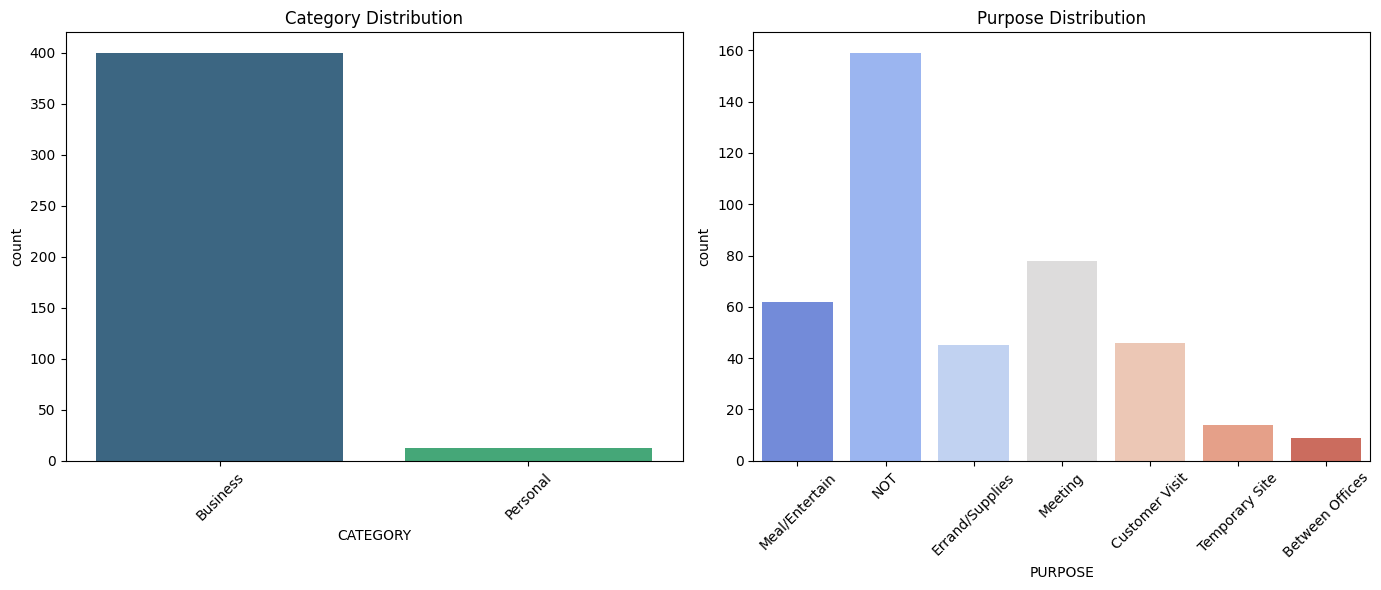

In [23]:


plt.figure(figsize=(14,6))

# CATEGORY
plt.subplot(1,2,1)
sns.countplot(
    data=dataset,
    x='CATEGORY',
    hue='CATEGORY',
    palette='viridis',
    legend=False
)
plt.title('Category Distribution')
plt.xticks(rotation=45)

# PURPOSE
plt.subplot(1,2,2)
sns.countplot(
    data=dataset,
    x='PURPOSE',
    hue='PURPOSE',
    palette='coolwarm',
    legend=False
)
plt.title('Purpose Distribution')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

(array([  0.,  20.,  40.,  60.,  80., 100., 120., 140., 160.]),
 [Text(0.0, 0, '0'),
  Text(20.0, 0, '20'),
  Text(40.0, 0, '40'),
  Text(60.0, 0, '60'),
  Text(80.0, 0, '80'),
  Text(100.0, 0, '100'),
  Text(120.0, 0, '120'),
  Text(140.0, 0, '140'),
  Text(160.0, 0, '160')])

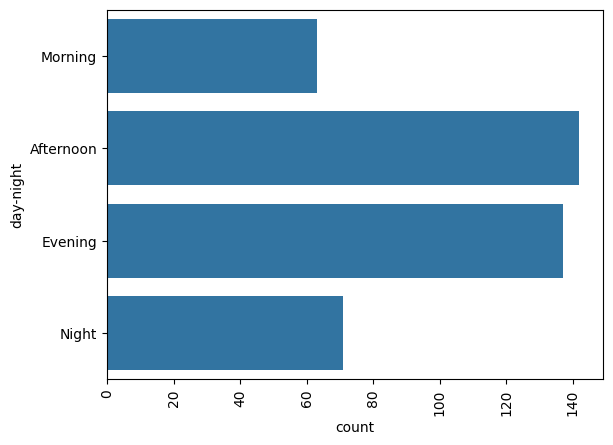

In [24]:
sns.countplot(dataset["day-night"])
plt.xticks(rotation=90)

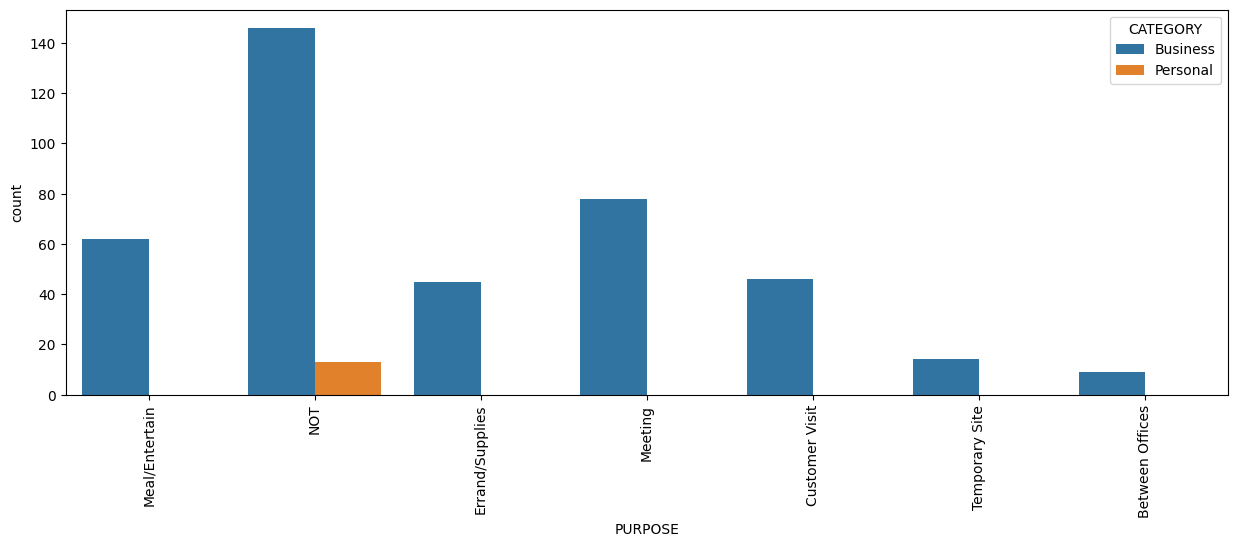

In [25]:
plt.figure(figsize=(15,5))
sns.countplot(dataset,x='PURPOSE',hue="CATEGORY")
plt.xticks(rotation=90)
plt.show()

In [27]:
from sklearn.preprocessing import OneHotEncoder


In [29]:

object_cols = ['CATEGORY', 'PURPOSE']

OH_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

OH_array = OH_encoder.fit_transform(dataset[object_cols])

OH_cols = pd.DataFrame(
    OH_array,
    index=dataset.index,
    columns=OH_encoder.get_feature_names_out(object_cols)
)

df_final = dataset.drop(object_cols, axis=1)

dataset = pd.concat([df_final, OH_cols], axis=1)



<Axes: >

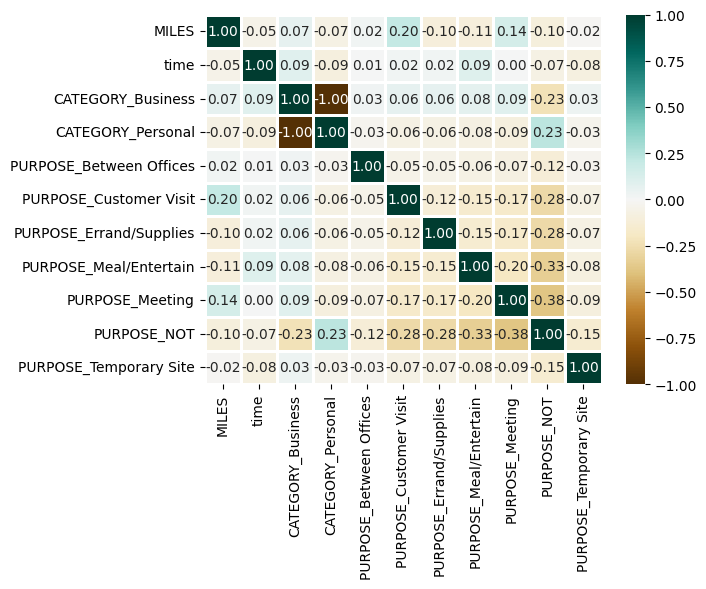

In [30]:

numeric_dataset = dataset.select_dtypes(include=['number'])

sns.heatmap(numeric_dataset.corr(),
            cmap='BrBG',
            fmt='.2f',
            linewidths=2,
            annot=True)




[Text(0.5, 0, 'MONTHS'), Text(0, 0.5, 'VALUE COUNT')]

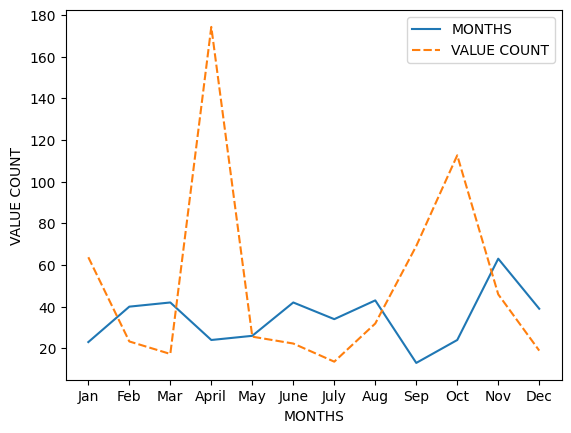

In [31]:
dataset['MONTH'] = pd.DatetimeIndex(dataset['START_DATE']).month
month_label = {1.0: 'Jan', 2.0: 'Feb', 3.0: 'Mar', 4.0: 'April',
               5.0: 'May', 6.0: 'June', 7.0: 'July', 8.0: 'Aug',
               9.0: 'Sep', 10.0: 'Oct', 11.0: 'Nov', 12.0: 'Dec'}
dataset["MONTH"] = dataset.MONTH.map(month_label)

mon = dataset.MONTH.value_counts(sort=False)

# Month total rides count vs Month ride max count
df = pd.DataFrame({"MONTHS": mon.values,
                   "VALUE COUNT": dataset.groupby('MONTH',
                                                  sort=False)['MILES'].max()})

p = sns.lineplot(data=df)
p.set(xlabel="MONTHS", ylabel="VALUE COUNT")

In [32]:
dataset['DAY'] = dataset.START_DATE.dt.weekday
day_label = {
    0: 'Mon', 1: 'Tues', 2: 'Wed', 3: 'Thus', 4: 'Fri', 5: 'Sat', 6: 'Sun'
}
dataset['DAY'] = dataset['DAY'].map(day_label)

Text(0, 0.5, 'COUNT')

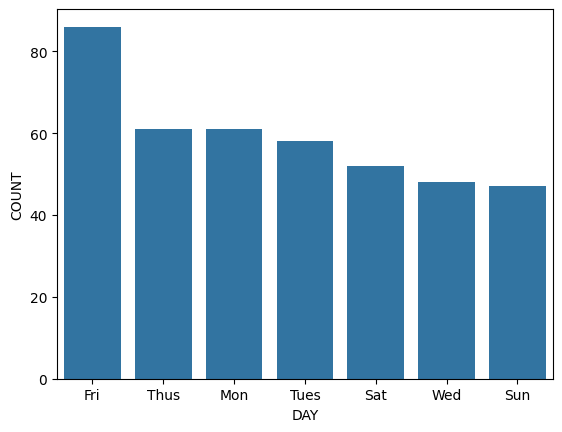

In [33]:
day_label = dataset.DAY.value_counts()
sns.barplot(x=day_label.index, y=day_label);
plt.xlabel('DAY')
plt.ylabel('COUNT')

<Axes: ylabel='MILES'>

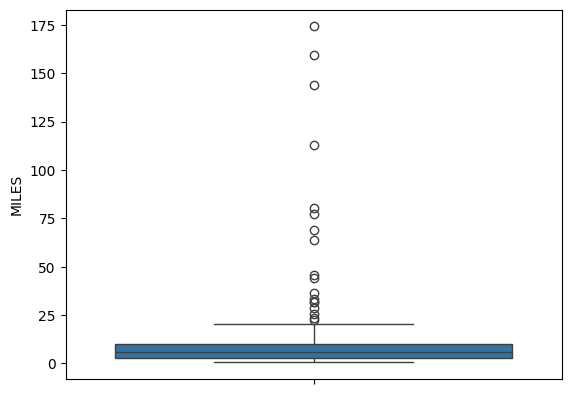

In [34]:
sns.boxplot(dataset['MILES'])

<Axes: ylabel='MILES'>

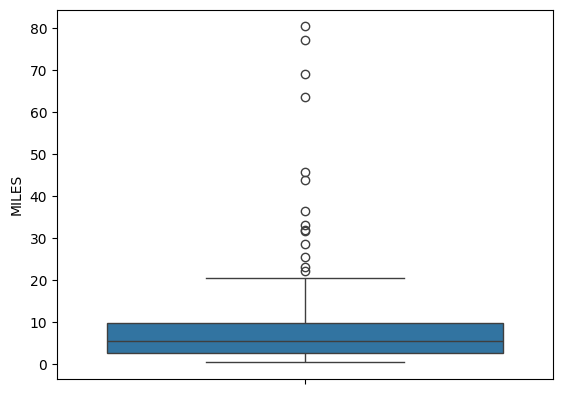

In [35]:
sns.boxplot(dataset[dataset['MILES']<100]['MILES'])